In [49]:
f_switch: float = 6.78e6     # 동작 주파수 [Hz]
delay_deg: float = 47        # ZVS 입력 위상 [deg]
V_load_target: float = 100   # 공진단 출력(=벅부스트 입력) 목표 전압 [Vrms]

# LCC-LCC (양면 LCC) 보상 설계 @ 6.78 MHz

WPT 공진단. 추출 코일 Z-행렬(`COIL.csv`)을 사용.  
**구조**: 인버터 → 1차 LCC(Lf1,Cf1,C1) → 코일 → 2차 LCC(C2,Cf2,Lf2) → 정류 → **벅부스트(조절)** → 부하

### 왜 LCC-LCC
- 1차 LCC: 인버터 전류를 작게(~2A) 유지 (9A 한계 여유). 코일전류는 탱크 순환.
- 2차 LCC: 실제 부하 R_L을 **코일이 보는 최적부하 R_eq,opt로 변환** → 코일은 최대효율점 유지하면서 **출력은 고전압·저전류**(정류·벅부스트 효율↑).
- 출력 특성: **CC**(정전류). 최종 조절은 뒷단 벅부스트가 담당.

### 튜닝 (공진점)
| 공진 | 소자 | 조건 |
|---|---|---|
| 1차 LC | Lf1↔Cf1 | ω₀²Lf1Cf1=1, **Cf1 디튠으로 ZVS** |
| 1차 CL | C1↔(L1−Lf1) | 6.78 정확 |
| 2차 CL | C2↔(L2−Lf2) | 6.78 정확 |
| 2차 LC | Lf2↔Cf2 | ω₀²Lf2Cf2=1 |

자유도: **Lf1**(전력), **Cf1 디튠**(25° ZVS), **Lf2**(부하전압/임피던스 변환).

## 1. 파라미터 + 코일 Z행렬

In [50]:
import csv, math, cmath
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

f0=f_switch; w=2*math.pi*f0; phi_tgt=delay_deg
Vin=2*math.sqrt(2)/math.pi*320     # 풀브릿지 ±320V 기본파 RMS
P_tgt=500.0

h,d=(lambda r:(r[0],r[1]))(list(csv.reader(open('COIL.csv'))))
def Zc(re,im): return float(d[h.index(re)])+1j*float(d[h.index(im)])
Z11=Zc('re(Zt(1_T1,1_T1)) []','im(Zt(1_T1,1_T1)) []')
Z22=Zc('re(Zt(2_T1,2_T1)) []','im(Zt(2_T1,2_T1)) []')
Z21=Zc('re(Zt(2_T1,1_T1)) []','im(Zt(2_T1,1_T1)) []'); Z12=Z21
R1,R2,wM=Z11.real,Z22.real,Z21.imag
print(f'Vin={Vin:.1f}V  f0={f0/1e6:.2f}MHz  목표 ZVS={phi_tgt}°  목표 부하전압={V_load_target}V')
print(f'Z11={Z11.real:.4f}{Z11.imag:+.2f}j  Z22={Z22.real:.4f}{Z22.imag:+.2f}j  ω0M={wM:.3f}Ω')

Vin=288.1V  f0=6.78MHz  목표 ZVS=47°  목표 부하전압=100V
Z11=0.0936+100.62j  Z22=0.0574+106.90j  ω0M=2.057Ω


## 2. 최적부하 R_eq,opt & 2차 LCC 설계

코일이 봐야 할 최대효율 부하 `R_eq,opt = R2√(1+kᵤ²)`.  
2차 Lf2가 실제부하 R_L을 변환: `R_eq = (ω₀Lf2)²/R_L`. 이를 R_eq,opt에 맞춤 → `Lf2 = √(R_eq,opt·R_L)/ω₀`.

In [51]:
FoM=wM**2/(R1*R2); eta_max=FoM/(1+math.sqrt(1+FoM))**2
Req=R2*math.sqrt(1+FoM)             # 코일이 봐야 할 최적부하
L1e=Z11.imag/w; L2e=Z22.imag/w      # 단자 유효 L

RL = V_load_target**2/P_tgt         # 실제 부하 (목표 전압에서)
Lf2= math.sqrt(Req*RL)/w            # 2차 Lf: RL -> Req 변환
Cf2= 1/(w**2*Lf2)
C2 = 1/(w**2*(L2e-Lf2))
print(f'kᵤ²={FoM:.0f}  η_max(링크)={eta_max*100:.1f}%')
print(f'코일 최적부하 R_eq,opt={Req:.3f}Ω   실제부하 R_L={RL:.2f}Ω (=>{V_load_target}V)')
print(f'2차: Lf2={Lf2*1e9:.1f}nH  Cf2={Cf2*1e12:.1f}pF  C2={C2*1e12:.1f}pF')

kᵤ²=787  η_max(링크)=93.1%
코일 최적부하 R_eq,opt=1.613Ω   실제부하 R_L=20.00Ω (=>100V)
2차: Lf2=133.3nH  Cf2=4133.2pF  C2=231.9pF


## 3. 전체 회로 해석기 (Z행렬 정확해)

코일=측정 Z행렬, 1차·2차 LCC 연결. `solve(Lf1,Cf1)` → 전 노드 전류·전력·입력위상.

In [52]:
def C1_(Lf1): return 1/(w**2*(L1e-Lf1))   # 1차 CL 동조 (Lf1 종속)

def solve(Lf1, Cf1):
    Y2 = 1j*w*Cf2 + 1/(1j*w*Lf2 + RL)        # nP2에서 본 부하측 어드미턴스
    G  = Y2/(1 + Y2/(1j*w*C2))                # C2 통과 후
    Zc_= Z11 - Z12*Z21*G/(1 + G*Z22)         # 코일 port1 입력임피던스
    Zt = Zc_ + 1/(1j*w*C1_(Lf1))
    I1 = Vin/(Zt*(1 - w**2*Lf1*Cf1) + 1j*w*Lf1)
    J2 = G*Z21*I1/(1 + G*Z22); I2 = -J2       # I2=코일2 전류
    VnP2 = J2/Y2; IRL = VnP2/(1j*w*Lf2 + RL)  # 부하전류
    I_in = I1*(1 + 1j*w*Cf1*Zt)               # 인버터 전류
    ICf2 = VnP2*1j*w*Cf2
    Pload= abs(IRL)**2*RL; Vload=abs(IRL)*RL
    Zin  = Vin/I_in
    return dict(I1=I1,I2=I2,IRL=IRL,ICf2=ICf2,I_in=I_in,Pload=Pload,Vload=Vload,
                Zin=Zin,phase=math.degrees(cmath.phase(Zin)),
                eta=Pload/(Vin*I_in.conjugate()).real, C1=C1_(Lf1))

## 4. 1차 해 찾기 — [∠Zin=25°, P=500W]

`Lf1`(전력)과 `Cf1`(25° 디튠)을 두 조건에 동시 맞춤.

In [53]:
def resid(x):
    r=solve(x[0],x[1]); return [r['phase']-phi_tgt, r['Pload']-P_tgt]
Lf10=Vin/(w*14.0); Cf10=1/(w**2*Lf10)
Lf1,Cf1=fsolve(resid,[Lf10,Cf10])
r=solve(Lf1,Cf1); C1=r['C1']; Cf1_t=1/(w**2*Lf1)
print(f'수렴: ∠Zin={r["phase"]:.2f}°  Pload={r["Pload"]:.1f}W')

수렴: ∠Zin=47.00°  Pload=500.0W


## 5. 설계 결과

In [54]:
print('=== LCC-LCC 소자값 @ {:.2f} MHz ==='.format(f0/1e6))
print(f'[1차]  Lf1={Lf1*1e6:.4f}µH  Cf1={Cf1*1e12:.1f}pF (동조{Cf1_t*1e12:.1f}, {(Cf1/Cf1_t-1)*100:+.1f}% 디튠)  C1={C1*1e12:.1f}pF')
print(f'[2차]  Lf2={Lf2*1e9:.1f}nH   Cf2={Cf2*1e12:.1f}pF   C2={C2*1e12:.1f}pF')
print(f'[부하] R_L={RL:.2f}Ω  (벅부스트 입력)')
print()
print('=== 동작점 ===')
print(f'∠Zin={r["phase"]:.2f}° (ZVS {phi_tgt}°)   Pload={r["Pload"]:.1f}W   η(링크)={r["eta"]*100:.1f}%')
print(f'출력: {r["Vload"]:.1f}V / {abs(r["IRL"]):.2f}A   <- 정류+벅부스트가 받는 값 (고전압·저전류)')
print(f'인버터: |I_in|={abs(r["I_in"]):.2f}A (9A 한계, 여유 {9/abs(r["I_in"]):.1f}배)')
print(f'코일전류: I_L1={abs(r["I1"]):.1f}A  I_L2={abs(r["I2"]):.1f}A   <- litz 정격 확인')
print(f'2차 부품 순환전류: Cf2={abs(r["ICf2"]):.1f}A (고전류 RF캡 필요)')

=== LCC-LCC 소자값 @ 6.78 MHz ===
[1차]  Lf1=0.4142µH  Cf1=1141.3pF (동조1330.3, -14.2% 디튠)  C1=282.9pF
[2차]  Lf2=133.3nH   Cf2=4133.2pF   C2=231.9pF
[부하] R_L=20.00Ω  (벅부스트 입력)

=== 동작점 ===
∠Zin=47.00° (ZVS 47°)   Pload=500.0W   η(링크)=93.1%
출력: 100.0V / 5.00A   <- 정류+벅부스트가 받는 값 (고전압·저전류)
인버터: |I_in|=2.73A (9A 한계, 여유 3.3배)
코일전류: I_L1=14.3A  I_L2=17.6A   <- litz 정격 확인
2차 부품 순환전류: Cf2=18.3A (고전류 RF캡 필요)


## 6. 주파수 응답 (ZVS 위상 확인)

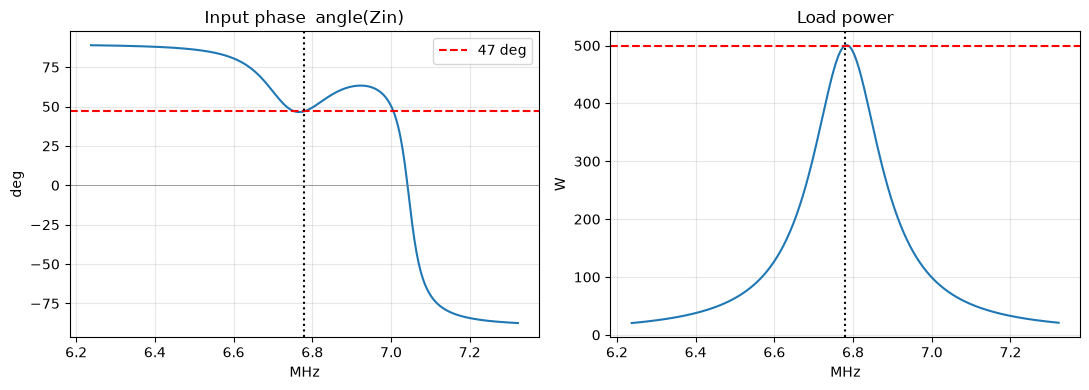

In [55]:
fr=np.linspace(0.92,1.08,401)*f0; ph=[];po=[];vo=[]
for fx in fr:
    ww=2*math.pi*fx
    Y2=1j*ww*Cf2+1/(1j*ww*Lf2+RL); G=Y2/(1+Y2/(1j*ww*C2))
    Zc_=Z11-Z12*Z21*G/(1+G*Z22); Zt=Zc_+1/(1j*ww*C1)
    I1=Vin/(Zt*(1-ww**2*Lf1*Cf1)+1j*ww*Lf1)
    J2=G*Z21*I1/(1+G*Z22); VnP2=J2/Y2; IRL=VnP2/(1j*ww*Lf2+RL)
    I_in=I1*(1+1j*ww*Cf1*Zt)
    ph.append(math.degrees(cmath.phase(Vin/I_in))); po.append(abs(IRL)**2*RL); vo.append(abs(IRL)*RL)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(fr/1e6,ph); ax[0].axhline(phi_tgt,color='r',ls='--',label=f'{phi_tgt} deg')
ax[0].axvline(f0/1e6,color='k',ls=':'); ax[0].axhline(0,color='gray',lw=.5)
ax[0].set_title('Input phase  angle(Zin)'); ax[0].set_xlabel('MHz'); ax[0].set_ylabel('deg'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(fr/1e6,po,label='P_load'); ax[1].axhline(P_tgt,color='r',ls='--'); ax[1].axvline(f0/1e6,color='k',ls=':')
ax[1].set_title('Load power'); ax[1].set_xlabel('MHz'); ax[1].set_ylabel('W'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. LTspice 넷리스트

코일은 단자 유효 L+R (Im(Z), Re(Z)) 로 단순 표기. 인버터=기본파 AC원.

In [56]:
k_coup=wM/(w*math.sqrt(L1e*L2e))
net=f'''* LCC-LCC @ {f0/1e6:.2f}MHz  Vin={Vin:.0f}Vrms  out={V_load_target:.0f}V/{P_tgt/V_load_target:.1f}A
Vin S 0 SINE(0 {Vin*math.sqrt(2):.1f} {f0:.0f})
* -- primary LCC --
Lf1 S  P1 {Lf1:.4g}
Cf1 P1 0  {Cf1:.4g}
C1  P1 T1 {C1:.4g}
Rtx T1 Tm {R1:.4g}
Ltx Tm 0  {L1e:.4g}
* -- secondary LCC --
Lrx Rm 0  {L2e:.4g}
Rrx Rx Rm {R2:.4g}
C2  Rx P2 {C2:.4g}
Cf2 P2 0  {Cf2:.4g}
Lf2 P2 Lo {Lf2:.4g}
RL  Lo 0  {RL:.4g}
K1  Ltx Lrx {k_coup:.4f}
.ac lin 401 {0.92*f0:.0f} {1.08*f0:.0f}
.end'''
print(net); open('LCC_LCC_6p78MHz.cir','w').write(net); print('\n-> LCC_LCC_6p78MHz.cir 저장')

* LCC-LCC @ 6.78MHz  Vin=288Vrms  out=100V/5.0A
Vin S 0 SINE(0 407.4 6780000)
* -- primary LCC --
Lf1 S  P1 4.142e-07
Cf1 P1 0  1.141e-09
C1  P1 T1 2.829e-10
Rtx T1 Tm 0.09362
Ltx Tm 0  2.362e-06
* -- secondary LCC --
Lrx Rm 0  2.509e-06
Rrx Rx Rm 0.05745
C2  Rx P2 2.319e-10
Cf2 P2 0  4.133e-09
Lf2 P2 Lo 1.333e-07
RL  Lo 0  20
K1  Ltx Lrx 0.0198
.ac lin 401 6237600 7322400
.end

-> LCC_LCC_6p78MHz.cir 저장
